# Customer Churn Analysis

## Objective
The objective of this project is to analyze customer behavior and identify the key factors associated with customer churn. The analysis will help understand which types of customers are more likely to leave and what actions a business can take to improve customer retention.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook
- VS Code


In [235]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns


In [236]:
df = pd.read_csv('../Data/04_CustomerChurn_Python_Data.csv')

# ----------------------------------------------------------------

### First 5 Rows
Checking the first 5 rows of the dataset.

In [237]:
df.head()

,Customer_ID,Age,City,Plan,Contract_Type,Tenure_Months,Monthly_Charge,Monthly_Usage_GB,Support_Calls,Complaints,Late_Payments,Credit_Score,Monthly_Income,Signup_Channel,Churn
0,CUST00001,40,Bengaluru,Basic,Monthly,45,299,11.1,3,1,3,518,89275,Web,Yes
1,CUST00002,57,Noida,Basic,Monthly,58,399,32.3,4,1,4,616,80708,App,No
2,CUST00003,52,Bengaluru,Standard,Monthly,37,699,29.5,1,2,1,660,145916,App,Yes
3,CUST00004,43,Chennai,Basic,Monthly,34,399,5.3,6,1,0,715,127875,App,Yes
4,CUST00005,26,Gurugram,Basic,Monthly,48,399,26.2,4,4,1,518,125707,App,No


# ----------------------------------------------------------------

### Last 5 Rows
Checking the last 5 rows of the dataset.

In [238]:
df.tail()

,Customer_ID,Age,City,Plan,Contract_Type,Tenure_Months,Monthly_Charge,Monthly_Usage_GB,Support_Calls,Complaints,Late_Payments,Credit_Score,Monthly_Income,Signup_Channel,Churn
1495,CUST01496,49,Gurugram,Standard,Annual,6,599,9.6,0,1,5,738,90342,Retail,Yes
1496,CUST01497,26,Kolkata,Premium,Monthly,30,1099,47.7,1,4,2,707,68788,Retail,No
1497,CUST01498,49,Chennai,Basic,Annual,20,349,9.2,2,5,3,516,80700,Retail,Yes
1498,CUST01499,51,Delhi,Basic,Quarterly,5,349,20.8,5,5,1,700,94382,Retail,No
1499,CUST01500,36,Hyderabad,Premium,Monthly,28,949,60.4,5,4,6,825,91942,Web,No


# ----------------------------------------------------------------

### Dataset Shape
Checking the total number of rows and columns.

In [239]:
df.shape

(1500, 15)

### Dataset Shape
The dataset contains 1500 rows and 15 columns.

# ----------------------------------------------------------------

### Column Names
Checking all available columns in the dataset.

In [240]:
df.columns

Index(['Customer_ID', 'Age', 'City', 'Plan', 'Contract_Type', 'Tenure_Months',
       'Monthly_Charge', 'Monthly_Usage_GB', 'Support_Calls', 'Complaints',
       'Late_Payments', 'Credit_Score', 'Monthly_Income', 'Signup_Channel',
       'Churn'],
      dtype='str')

### Available Columns
The dataset contains customer details, plan information, usage, payment behavior, support activity, and churn status.

# ----------------------------------------------------------------

### Data Types
Checking the data type of each column.

In [241]:
df.dtypes

Customer_ID             str
Age                   int64
City                    str
Plan                    str
Contract_Type           str
Tenure_Months         int64
Monthly_Charge        int64
Monthly_Usage_GB    float64
Support_Calls         int64
Complaints            int64
Late_Payments         int64
Credit_Score          int64
Monthly_Income        int64
Signup_Channel          str
Churn                   str
dtype: object

# ----------------------------------------------------------------

### Dataset Information
Checking column names, non-null values, and data types.

In [242]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer_ID       1500 non-null   str    
 1   Age               1500 non-null   int64  
 2   City              1480 non-null   str    
 3   Plan              1500 non-null   str    
 4   Contract_Type     1500 non-null   str    
 5   Tenure_Months     1500 non-null   int64  
 6   Monthly_Charge    1500 non-null   int64  
 7   Monthly_Usage_GB  1500 non-null   float64
 8   Support_Calls     1500 non-null   int64  
 9   Complaints        1500 non-null   int64  
 10  Late_Payments     1500 non-null   int64  
 11  Credit_Score      1500 non-null   int64  
 12  Monthly_Income    1500 non-null   int64  
 13  Signup_Channel    1500 non-null   str    
 14  Churn             1500 non-null   str    
dtypes: float64(1), int64(8), str(6)
memory usage: 175.9 KB


# ----------------------------------------------------------------

### Statistical Summary
Checking the basic statistics of numeric columns.

In [243]:
df.describe()

,Age,Tenure_Months,Monthly_Charge,Monthly_Usage_GB,Support_Calls,Complaints,Late_Payments,Credit_Score,Monthly_Income
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,39.078667,30.813333,649.766667,35.786800,4.015333,2.484667,3.014667,648.795333,84844.591333
std,12.478419,17.435820,285.981822,19.022479,2.601463,1.704416,2.007604,113.472735,37609.174843
min,18.000000,1.000000,249.000000,0.000000,0.000000,0.000000,0.000000,450.000000,18027.000000
25%,28.000000,16.000000,349.000000,21.050000,2.000000,1.000000,1.000000,552.000000,53059.250000
50%,39.000000,31.000000,599.000000,34.900000,4.000000,3.000000,3.000000,647.000000,83335.500000
75%,50.000000,46.000000,999.000000,49.825000,6.000000,4.000000,5.000000,742.250000,117923.750000
max,60.000000,60.000000,1099.000000,87.000000,8.000000,5.000000,6.000000,850.000000,149785.000000


# ----------------------------------------------------------------

## Data Understanding
Identifying important columns and their role in churn analysis.

# ----------------------------------------------------------------

## Data Quality Check
Checking missing values, duplicates, data types, and invalid values.

In [244]:
df.isnull().sum()

Customer_ID          0
Age                  0
City                20
Plan                 0
Contract_Type        0
Tenure_Months        0
Monthly_Charge       0
Monthly_Usage_GB     0
Support_Calls        0
Complaints           0
Late_Payments        0
Credit_Score         0
Monthly_Income       0
Signup_Channel       0
Churn                0
dtype: int64

In [245]:
df.isnull().sum()['City'] / df.shape[0] * 100

np.float64(1.3333333333333335)

### Missing Values
Only the `City` column contains missing values, affecting about 1.33% of the dataset.

# ----------------------------------------------------------------

### Duplicate Check
Checking whether any duplicate rows are present in the dataset.

In [246]:
df.duplicated().sum()

np.int64(0)

### Duplicate Check
No duplicate rows were found in the dataset.

# ----------------------------------------------------------------

### Blank String Check
Checking text columns for empty or blank values.

In [247]:
(df['City'].str.strip() == '').sum()

np.int64(0)

### Blank String Check
No blank string values were found in the `City` column.

# ----------------------------------------------------------------

### Category Consistency Check
Checking categorical columns for inconsistent values.

In [248]:
df['City'].value_counts(dropna=False)

City
Bengaluru    165
Jaipur       161
Mumbai       159
Gurugram     155
Pune         152
Kolkata      149
Chennai      140
Noida        138
Hyderabad    132
Delhi        129
NaN           20
Name: count, dtype: int64

### City Category Check
City categories are consistent, with 20 missing values and no obvious duplicate formats.

# ----------------------------------------------------------------

### Other Category Checks
Checking consistency in other categorical columns.

In [249]:
df['Plan'].value_counts(dropna=False)
df['Contract_Type'].value_counts(dropna=False)
df['Signup_Channel'].value_counts(dropna=False)
df['Churn'].value_counts(dropna=False)

df['Plan'].value_counts(dropna=False)
df['Contract_Type'].value_counts(dropna=False)
df['Signup_Channel'].value_counts(dropna=False)

print("Plan")
print(df['Plan'].value_counts(dropna=False))

print("\nContract Type")
print(df['Contract_Type'].value_counts(dropna=False))

print("\nSignup Channel")
print(df['Signup_Channel'].value_counts(dropna=False))

print("\nChurn")
print(df['Churn'].value_counts(dropna=False))

Plan
Plan
Standard    507
Premium     489
Basic       482
standard     10
basic         7
premium       5
Name: count, dtype: int64

Contract Type
Contract_Type
Quarterly    508
Annual       501
Monthly      491
Name: count, dtype: int64

Signup Channel
Signup_Channel
App       515
Web       494
Retail    491
Name: count, dtype: int64

Churn
Churn
No     1104
Yes     396
Name: count, dtype: int64


### Category Consistency
The `Plan` column contains inconsistent capitalization, while the other categorical columns are consistent.

# ----------------------------------------------------------------

### Numeric Value Check
Checking numeric columns for invalid or suspicious values.

In [250]:
df[['Age', 'Tenure_Months', 'Monthly_Charge', 'Monthly_Usage_GB',
    'Support_Calls', 'Complaints', 'Late_Payments',
    'Credit_Score', 'Monthly_Income']].agg(['min', 'max'])

,Age,Tenure_Months,Monthly_Charge,Monthly_Usage_GB,Support_Calls,Complaints,Late_Payments,Credit_Score,Monthly_Income
min,18,1,249,0.0,0,0,0,450,18027
max,60,60,1099,87.0,8,5,6,850,149785


### Numeric Value Check
No obvious invalid or negative numeric values were found.

# ----------------------------------------------------------------

## Data Cleaning
Cleaning missing and inconsistent values before analysis.

In [251]:
df['Plan'] = df['Plan'].str.title()
df['Plan'].value_counts()

Plan
Standard    517
Premium     494
Basic       489
Name: count, dtype: int64

# ----------------------------------------------------------------

### Missing City Values
Handling missing values in the `City` column carefully.

In [252]:
df[df['City'].isnull()]

,Customer_ID,Age,City,Plan,Contract_Type,Tenure_Months,Monthly_Charge,Monthly_Usage_GB,Support_Calls,Complaints,Late_Payments,Credit_Score,Monthly_Income,Signup_Channel,Churn
81,CUST00082,51,NaN,Standard,Annual,11,699,4.4,0,3,1,581,133564,App,No
144,CUST00145,26,NaN,Standard,Annual,28,699,34.5,4,0,3,623,63011,Web,No
182,CUST00183,26,NaN,Standard,Quarterly,19,599,48.5,4,4,2,610,90274,Web,Yes
186,CUST00187,60,NaN,Basic,Annual,4,249,27.8,4,3,1,696,102565,App,No
499,CUST00500,31,NaN,Basic,Quarterly,39,299,6.7,8,0,4,670,100063,App,No
587,CUST00588,25,NaN,Basic,Quarterly,15,299,18.5,3,0,6,463,63284,Web,No
657,CUST00658,45,NaN,Basic,Annual,40,299,29.3,7,5,5,506,33353,Retail,No
780,CUST00781,19,NaN,Basic,Monthly,10,249,14.5,4,4,2,514,133925,Retail,No
788,CUST00789,50,NaN,Standard,Monthly,4,599,21.3,2,3,3,563,84153,App,No
796,CUST00797,21,NaN,Standard,Monthly,23,649,33.8,5,5,4,826,83711,Web,Yes


### City Missing Values
Missing city values were replaced with `Unknown` instead of dropping customer records.

In [253]:
df['City'] = df['City'].fillna('Unknown')
df['City'].isnull().sum()

np.int64(0)

# ----------------------------------------------------------------

### Remove Extra Column
Removing the accidentally created duplicate `plan` column.

In [254]:
df.drop(columns=['Plan'], inplace=True)

In [255]:
df.columns

Index(['Customer_ID', 'Age', 'City', 'Contract_Type', 'Tenure_Months',
       'Monthly_Charge', 'Monthly_Usage_GB', 'Support_Calls', 'Complaints',
       'Late_Payments', 'Credit_Score', 'Monthly_Income', 'Signup_Channel',
       'Churn'],
      dtype='str')

In [256]:
df_original = pd.read_csv('../Data/04_CustomerChurn_Python_Data.csv')

df['Plan'] = df_original['Plan'].str.title()

In [257]:
df.columns
df['Plan'].value_counts()

Plan
Standard    517
Premium     494
Basic       489
Name: count, dtype: int64

# ----------------------------------------------------------------

### Cleaned DataFrame
Creating a cleaned copy of the dataset for analysis.

In [258]:
df_clean = df.copy()

In [259]:
df_clean.shape
df_clean.isnull().sum()

Customer_ID         0
Age                 0
City                0
Contract_Type       0
Tenure_Months       0
Monthly_Charge      0
Monthly_Usage_GB    0
Support_Calls       0
Complaints          0
Late_Payments       0
Credit_Score        0
Monthly_Income      0
Signup_Channel      0
Churn               0
Plan                0
dtype: int64

### Cleaning Complete
The cleaned dataset contains no missing values and is ready for analysis.

# ----------------------------------------------------------------

## Basic Churn Analysis
Calculating total customers, churned customers, retained customers, churn rate, and retention rate.

In [260]:
total_customers = df_clean.shape[0]

churned_customers = (df_clean['Churn'] == 'Yes').sum()

retained_customers = (df_clean['Churn'] == 'No').sum()

churn_rate = (churned_customers / total_customers) * 100

retention_rate = (retained_customers / total_customers) * 100

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Retained Customers:", retained_customers)
print("Churn Rate:", round(churn_rate, 2), "%")
print("Retention Rate:", round(retention_rate, 2), "%")

Total Customers: 1500
Churned Customers: 396
Retained Customers: 1104
Churn Rate: 26.4 %
Retention Rate: 73.6 %


### Observation
Out of 1,500 customers, 396 customers churned and 1,104 customers were retained. The overall churn rate is 26.4%.

# ----------------------------------------------------------------

### Churn by Contract Type
Analyzing how customer churn varies across different contract types.

In [261]:
contract_churn = pd.crosstab(
    df_clean['Contract_Type'],
    df_clean['Churn'],
    normalize='index'
) * 100

contract_churn

Churn,No,Yes
Contract_Type,,
Annual,75.449102,24.550898
Monthly,68.024440,31.975560
Quarterly,77.165354,22.834646


In [262]:
contract_churn['Yes'].sort_values(ascending=False)

Contract_Type
Monthly      31.975560
Annual       24.550898
Quarterly    22.834646
Name: Yes, dtype: float64

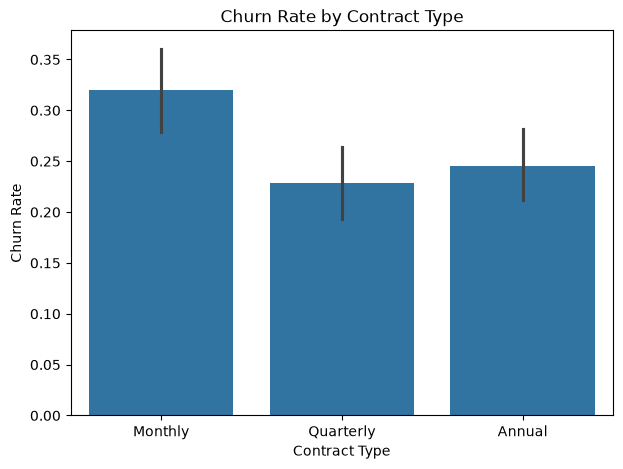

In [263]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df_clean,
    x='Contract_Type',
    y=df_clean['Churn'].eq('Yes')
)

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate')
plt.savefig('../Images/churn_by_contract.png', bbox_inches='tight')
plt.show()


**Observation:** Monthly contract customers have the highest churn rate at 31.98%, while quarterly customers have the lowest churn rate at 22.83%.

**Insight:** Customers with monthly contracts appear less likely to stay compared with customers on longer contract types.

**Recommendation:** The company can encourage monthly customers to move to quarterly or annual contracts through suitable retention offers.

# ----------------------------------------------------------------

### Churn by Plan
Analyzing churn rates across different customer plans.

In [264]:
plan_churn = pd.crosstab(
    df_clean['Plan'],
    df_clean['Churn'],
    normalize='index'
) * 100

plan_churn

Churn,No,Yes
Plan,,
Basic,74.233129,25.766871
Premium,76.720648,23.279352
Standard,70.019342,29.980658


In [265]:
plan_churn['Yes'].sort_values(ascending=False)

Plan
Standard    29.980658
Basic       25.766871
Premium     23.279352
Name: Yes, dtype: float64

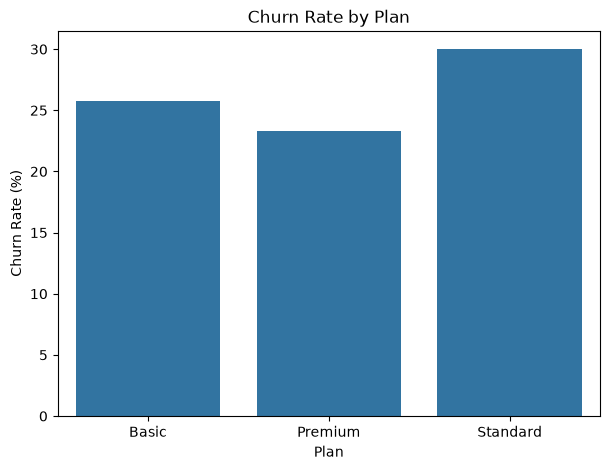

In [266]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=plan_churn.index,
    y=plan_churn['Yes']
)

plt.title('Churn Rate by Plan')
plt.xlabel('Plan')
plt.ylabel('Churn Rate (%)')
plt.savefig('../Images/churn_by_plan.png', bbox_inches='tight')
plt.show()

**Observation:** Standard plan customers have the highest churn rate at 29.98%, while Premium plan customers have the lowest churn rate at 23.28%.

**Insight:** Churn differs across customer plans, with Standard plan customers showing relatively higher churn.

**Recommendation:** The company should investigate the Standard plan experience, pricing, and benefits to understand why churn is higher in this segment.

# ----------------------------------------------------------------

### Churn by Signup Channel
Analyzing churn rates across different signup channels.

In [267]:
signup_churn = pd.crosstab(
    df_clean['Signup_Channel'],
    df_clean['Churn'],
    normalize='index'
) * 100

signup_churn

Churn,No,Yes
Signup_Channel,,
App,71.067961,28.932039
Retail,76.171079,23.828921
Web,73.684211,26.315789


In [268]:
signup_churn['Yes'].sort_values(ascending=False)

Signup_Channel
App       28.932039
Web       26.315789
Retail    23.828921
Name: Yes, dtype: float64

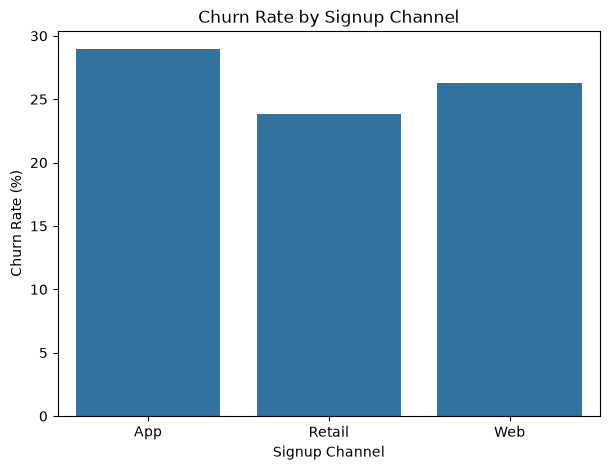

In [269]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=signup_churn.index,
    y=signup_churn['Yes']
)

plt.title('Churn Rate by Signup Channel')
plt.xlabel('Signup Channel')
plt.ylabel('Churn Rate (%)')
plt.savefig('../Images/churn_by_signup_channel.png', bbox_inches='tight')
plt.show()

**Observation:** Customers who signed up through the App have the highest churn rate at 28.93%, while Retail customers have the lowest churn rate at 23.83%.

**Insight:** Signup channel appears to be associated with different churn levels, with App users showing relatively higher churn.

**Recommendation:** The company should review the App onboarding experience, communication, and service quality to identify possible reasons for higher churn.

# ----------------------------------------------------------------

### Churn by City
Analyzing churn rates across different cities.

In [270]:
city_churn = pd.crosstab(
    df_clean['City'],
    df_clean['Churn'],
    normalize='index'
) * 100

city_churn['Yes'].sort_values(ascending=False)

City
Chennai      32.857143
Jaipur       31.677019
Bengaluru    28.484848
Gurugram     28.387097
Noida        26.811594
Mumbai       25.786164
Hyderabad    25.757576
Delhi        24.806202
Kolkata      22.818792
Pune         17.763158
Unknown      15.000000
Name: Yes, dtype: float64

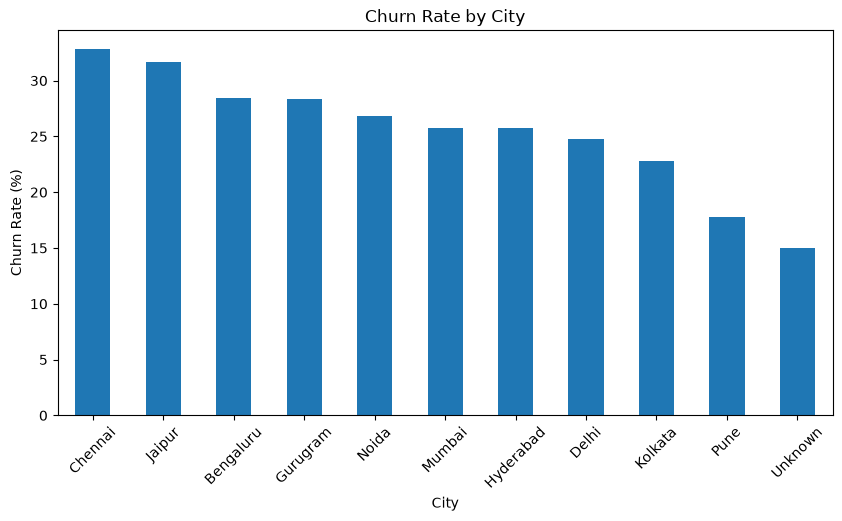

In [271]:
plt.figure(figsize=(10,5))

city_churn['Yes'].sort_values(ascending=False).plot(kind='bar')

plt.title('Churn Rate by City')
plt.xlabel('City')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.savefig('../Images/churn_by_city.png', bbox_inches='tight')
plt.show()

**Observation:** Chennai has the highest churn rate at 32.86%, followed by Jaipur at 31.68%. Pune has the lowest churn rate among known cities at 17.76%.

**Insight:** Churn varies noticeably across cities, suggesting that location-specific customer experience or market conditions may be associated with retention.

**Recommendation:** The company should investigate service quality, support issues, pricing, and customer experience in high-churn cities such as Chennai and Jaipur.

# ----------------------------------------------------------------

### Tenure Analysis
Comparing customer tenure between churned and retained customers.

In [272]:
df_clean.groupby('Churn')['Tenure_Months'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
Churn,,,,
No,30.903986,31.0,1,60
Yes,30.560606,32.5,1,60


**Observation:** Churned and retained customers have very similar average tenure, around 31 months.

**Insight:** Tenure does not appear to have a strong relationship with churn in this dataset.

**Recommendation:** The company should not rely on tenure alone to identify high-risk customers and should combine it with factors such as complaints, support calls, contract type, and charges.

# ----------------------------------------------------------------

### Monthly Charge Analysis
Comparing monthly charges between churned and retained customers.

In [273]:
df_clean.groupby('Churn')['Monthly_Charge'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
Churn,,,,
No,654.434783,599.0,249,1099
Yes,636.752525,599.0,249,1099


**Observation:** Churned customers have an average monthly charge of ₹636.75, compared with ₹654.43 for retained customers. The median monthly charge is ₹599 for both groups.

**Insight:** Monthly charges alone do not show a strong difference between churned and retained customers in this dataset.

**Recommendation:** The company should combine monthly charges with factors such as contract type, complaints, and support activity when identifying customers at risk of churn.

# ----------------------------------------------------------------

### Complaints Analysis
Comparing the number of complaints between churned and retained customers.

In [274]:
df_clean.groupby('Churn')['Complaints'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
Churn,,,,
No,2.301630,2.0,0,5
Yes,2.994949,3.0,0,5


**Observation:** Churned customers made more complaints on average than retained customers.

**Insight:** Higher complaint levels are associated with higher churn in this dataset.

**Recommendation:** The company should prioritize customers with repeated complaints and resolve their issues quickly to reduce churn risk.

# ----------------------------------------------------------------

### Support Calls Analysis
Comparing support call activity between churned and retained customers.

In [275]:
df_clean.groupby('Churn')['Support_Calls'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
Churn,,,,
No,3.956522,4.0,0,8
Yes,4.179293,4.0,0,8


**Observation:** Churned customers made slightly more support calls on average than retained customers.

**Insight:** Higher support activity may indicate customer issues, but the difference is relatively small.

**Recommendation:** Support call frequency should be used together with complaints and contract type to identify customers at higher churn risk.

# ----------------------------------------------------------------

### Late Payments Analysis
Comparing late payment behavior between churned and retained customers.

In [276]:
df_clean.groupby('Churn')['Late_Payments'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
Churn,,,,
No,2.861413,3.0,0,6
Yes,3.441919,4.0,0,6


**Observation:** Churned customers had more late payments on average than retained customers.

**Insight:** Frequent late payments are associated with higher churn in this dataset.

**Recommendation:** The company can flag customers with repeated late payments and offer payment reminders or flexible payment options.

# ----------------------------------------------------------------

### Credit Score Analysis
Comparing credit scores between churned and retained customers.

In [277]:
df_clean.groupby('Churn')['Credit_Score'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
Churn,,,,
No,645.792572,645.5,450,850
Yes,657.166667,654.0,450,850


**Observation:** Churned customers have a slightly higher average credit score than retained customers.

**Insight:** Credit score does not appear to be a strong standalone indicator of churn in this dataset.

**Recommendation:** The company should not use credit score alone for churn targeting and should combine it with behavioral factors such as complaints and late payments.

# ----------------------------------------------------------------

### Monthly Income Analysis
Comparing monthly income between churned and retained customers.

In [278]:
df_clean.groupby('Churn')['Monthly_Income'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
Churn,,,,
No,84456.315217,83020.5,18027,149785
Yes,85927.058081,85692.5,19158,149780


**Observation:** Churned customers have a slightly higher average monthly income than retained customers.

**Insight:** Monthly income does not show a strong difference between churned and retained customers in this dataset.

**Recommendation:** Income should not be used alone to identify churn risk. Behavioral factors such as complaints and late payments appear more useful.

# ----------------------------------------------------------------

### Monthly Usage Analysis
Comparing monthly data usage between churned and retained customers.

In [279]:
df_clean.groupby('Churn')['Monthly_Usage_GB'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
Churn,,,,
No,36.068569,35.2,0.0,85.3
Yes,35.001263,34.8,0.0,87.0


**Observation:** Monthly data usage is very similar for churned and retained customers.

**Insight:** Monthly usage does not appear to be a strong standalone churn indicator in this dataset.

**Recommendation:** The company should focus more on behavioral factors such as complaints, late payments, and contract type when identifying churn risk.

# ----------------------------------------------------------------

## Visualizations

### Churn Distribution
Showing the number of churned and retained customers.

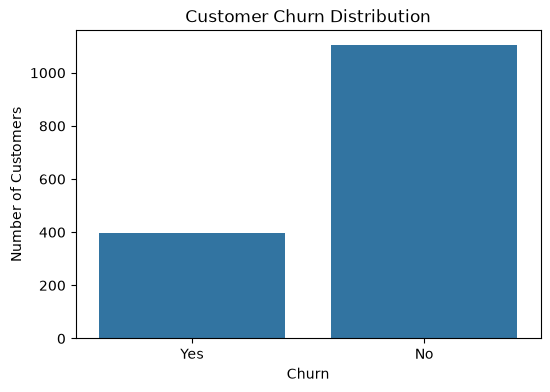

In [280]:
plt.figure(figsize=(6,4))

sns.countplot(data=df_clean, x='Churn')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.savefig('../Images/churn_distribution.png', bbox_inches='tight')
plt.show()

**Observation:** Retained customers are much higher in number than churned customers.

**Insight:** The dataset is imbalanced, with more non-churned customers than churned customers.

**Recommendation:** Churn-focused retention strategies should target the smaller but important group of customers showing high-risk behavior.

# ----------------------------------------------------------------

### Churn Percentage
Showing the percentage of churned and retained customers.

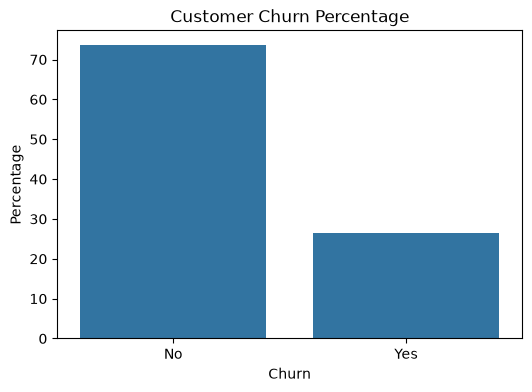

In [281]:
churn_percent = df_clean['Churn'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))

sns.barplot(
    x=churn_percent.index,
    y=churn_percent.values
)

plt.title('Customer Churn Percentage')
plt.xlabel('Churn')
plt.ylabel('Percentage')

plt.savefig('../Images/churn_percentage.png', bbox_inches='tight')
plt.show()

**Observation:** 26.4% of customers churned, while 73.6% were retained.

**Insight:** More than one-fourth of the customer base has churned, which is significant for the business.

**Recommendation:** The company should focus retention efforts on customer groups with higher churn rates, especially monthly-contract customers and customers with more complaints or late payments.

# ----------------------------------------------------------------

### Complaints vs Churn
Comparing complaint distribution between churned and retained customers.

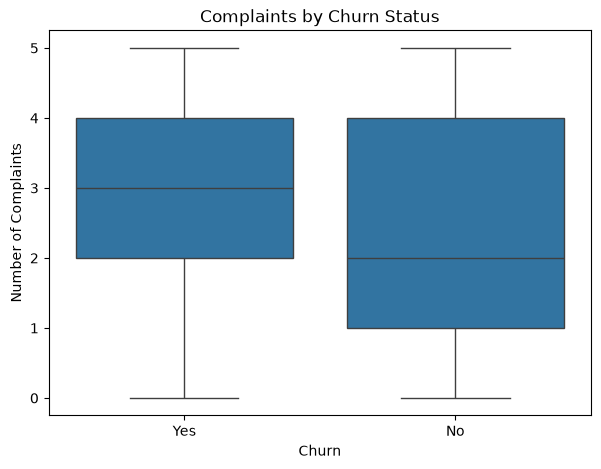

In [282]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df_clean,
    x='Churn',
    y='Complaints'
)

plt.title('Complaints by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Number of Complaints')

plt.savefig('../Images/complaints_vs_churn.png', bbox_inches='tight')
plt.show()

**Observation:** Churned customers generally show a higher number of complaints than retained customers.

**Insight:** More complaints are associated with higher churn, making complaints a useful customer-risk signal.

**Recommendation:** The company should prioritize customers with repeated complaints and improve issue resolution speed.

# ----------------------------------------------------------------

### Late Payments vs Churn
Comparing late payment behavior between churned and retained customers.

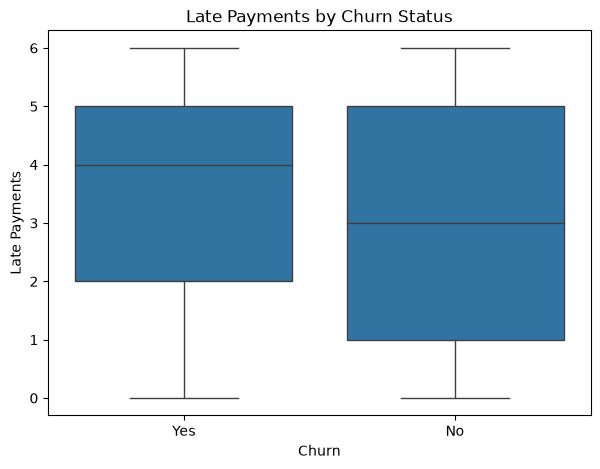

In [283]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df_clean,
    x='Churn',
    y='Late_Payments'
)

plt.title('Late Payments by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Late Payments')

plt.savefig('../Images/late_payments_vs_churn.png', bbox_inches='tight')
plt.show()

**Observation:** Churned customers generally have more late payments than retained customers.

**Insight:** Frequent late payments are associated with higher churn.

**Recommendation:** The company can use payment reminders and flexible payment options for customers with repeated late payments.

# ----------------------------------------------------------------

### Tenure Distribution by Churn
Comparing tenure distribution for churned and retained customers.

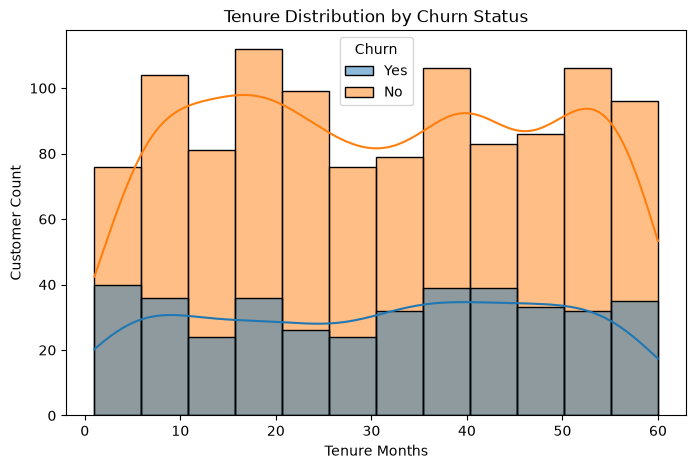

In [284]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_clean,
    x='Tenure_Months',
    hue='Churn',
    kde=True
)

plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Tenure Months')
plt.ylabel('Customer Count')

plt.savefig('../Images/tenure_distribution.png', bbox_inches='tight')
plt.show()

**Observation:** The tenure distribution is quite similar for churned and retained customers.

**Insight:** Tenure does not appear to strongly separate churned customers from retained customers in this dataset.

**Recommendation:** Tenure should be combined with stronger behavioral indicators such as complaints and late payments.

# ----------------------------------------------------------------

### Correlation Heatmap
Checking relationships between numeric variables.

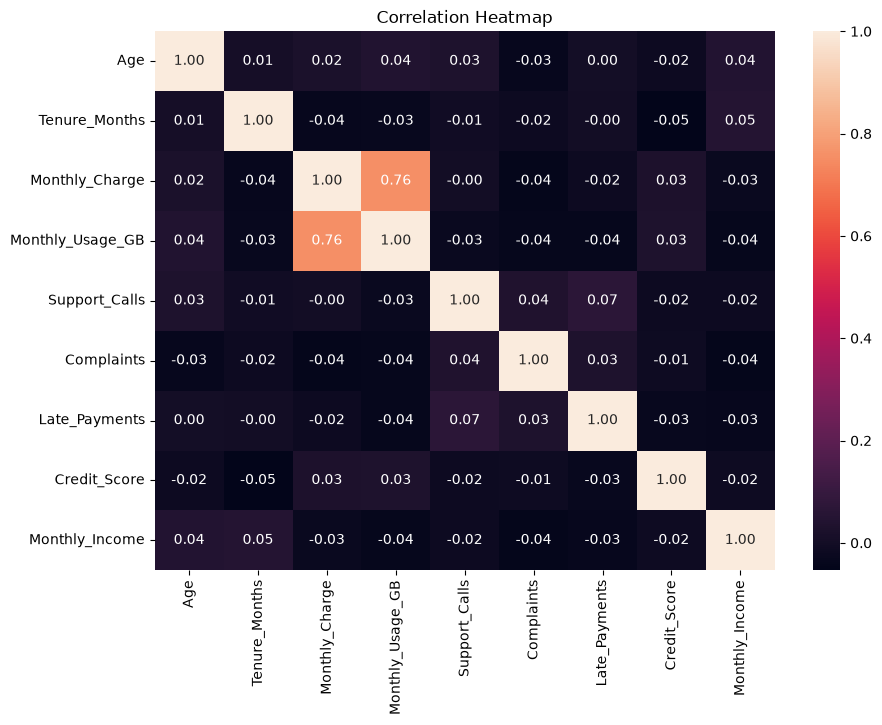

In [285]:
numeric_cols = [
    'Age',
    'Tenure_Months',
    'Monthly_Charge',
    'Monthly_Usage_GB',
    'Support_Calls',
    'Complaints',
    'Late_Payments',
    'Credit_Score',
    'Monthly_Income'
]

plt.figure(figsize=(10,7))

sns.heatmap(
    df_clean[numeric_cols].corr(),
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.savefig('../Images/correlation_heatmap.png', bbox_inches='tight')
plt.show()

**Observation:** The heatmap shows the strength and direction of relationships between numeric variables.

**Insight:** Most numeric variables should be interpreted carefully because correlation does not mean causation.

**Recommendation:** Stronger relationships, if any, can be investigated further along with churn-focused analysis.

# ----------------------------------------------------------------

## Business Questions

1. What is the overall customer churn rate?
2. Which contract type has the highest churn rate?
3. Which customer plan has the highest churn rate?
4. Which signup channel has the highest churn rate?
5. Which cities have the highest churn rates?
6. Do customers with more complaints churn more?
7. Are late payments associated with higher churn?
8. Does customer tenure strongly affect churn?

## Key Insights

1. The overall customer churn rate is 26.4%.
2. Monthly contract customers have the highest churn rate at 31.98%.
3. Standard plan customers have the highest churn rate at 29.98%.
4. Chennai and Jaipur show the highest churn rates among known cities.
5. Churned customers have more complaints and more late payments on average than retained customers.
6. Tenure, monthly usage, monthly income, and credit score show relatively small differences between churned and retained customers.

## Business Recommendations

1. Focus retention efforts on monthly contract customers.
2. Investigate the Standard plan to understand why churn is higher in this segment.
3. Prioritize customers with repeated complaints for faster issue resolution.
4. Use late-payment behavior as an additional churn-risk signal.
5. Review customer experience in high-churn cities such as Chennai and Jaipur.

# ----------------------------------------------------------------

## Export
Saving the cleaned dataset for future use.

In [286]:
df_clean.to_csv('../Output/customer_churn_cleaned.csv', index=False)